# DDS Optimization Results Analysis

This notebook analyzes parameter calibration results from CONFLUENCE DDS optimization runs.

## Key Analyses:
1. **Convergence History** - How NSE improved over iterations
2. **Best Parameters** - Optimal values found by optimization
3. **Parameter Sensitivity** - Which parameters matter most
4. **Model Validation** - Best-fit model performance vs observations

In [ ]:
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import yaml
import warnings

warnings.filterwarnings('ignore')

# Configuration
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/')
CONFLUENCE_CODE_DIR = Path('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
DOMAIN_NAME = 'Tuolumne_River_lumped'
CONFIG_PATH = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne_lumped_v1.yaml'

# Load configuration
with open(CONFIG_PATH, 'r') as f:
    config_dict = yaml.safe_load(f)

project_dir = CONFLUENCE_DATA_DIR / f"domain_{DOMAIN_NAME}"
opt_dir = project_dir / "optimisation"

print(f"Project directory: {project_dir}")
print(f"Optimization directory: {opt_dir}")
print(f"Optimization config: {config_dict['EXPERIMENT_ID']}")

# Get optimization algorithm from config
OPTIMIZATION_ALGORITHM_FROM_CONFIG = config_dict.get('ITERATIVE_OPTIMIZATION_ALGORITHM', 'DDS')
print(f"Optimization algorithm (from config): {OPTIMIZATION_ALGORITHM_FROM_CONFIG}")

Project directory: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped
Optimization directory: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/optimisation
Optimization config: 20260225_spongy_parkingLot


## Configuration: Choose Optimization Algorithm

**Before running the full analysis, choose which algorithm your optimization used:**
- **DDS** (Dynamical Dimensioned Search) - Sequential, intelligent search. ⚠️ Use `MPI_PROCESSES: 1`
- **PSO** (Particle Swarm Optimization) - Parallel-friendly, population-based
- **SCE** (Shuffled Complex Evolution) - Parallel-friendly, evolutionary
- **GA** (Genetic Algorithm) - Parallel-friendly, evolutionary

See next cell for configuration.

In [ ]:
# ===== USER CONFIGURATION =====
# Set which optimization algorithm was used in your run
# Choose from: 'DDS', 'PSO', 'SCE', 'GA'
OPTIMIZATION_ALGORITHM = OPTIMIZATION_ALGORITHM_FROM_CONFIG

# Update config_dict with actual algorithm from config file
# (will read from loaded config in next steps)
ALGORITHM_NOTES = {
    'DDS': {
        'name': 'Dynamical Dimensioned Search',
        'parallel': False,
        'recommendation': 'Set MPI_PROCESSES=1 in config',
        'best_for': 'Sequential, intelligent parameter search',
        'caution': 'Parallel DDS degrades convergence!'
    },
    'PSO': {
        'name': 'Particle Swarm Optimization',
        'parallel': True,
        'recommendation': 'Can use MPI_PROCESSES > 1',
        'best_for': 'Parallel searches with population dynamics',
        'caution': 'Tuning: cognitive/social parameters matter'
    },
    'SCE': {
        'name': 'Shuffled Complex Evolution',
        'parallel': True,
        'recommendation': 'Can use MPI_PROCESSES > 1',
        'best_for': 'Robust global search with adaptive sampling',
        'caution': 'More iterations needed than DDS'
    },
    'GA': {
        'name': 'Genetic Algorithm',
        'parallel': True,
        'recommendation': 'Can use MPI_PROCESSES > 1',
        'best_for': 'Parallel searches with crossover/mutation',
        'caution': 'Population size affects convergence'
    }
}

print("\n" + "="*70)
print("⚙️  OPTIMIZATION ALGORITHM CONFIGURATION")
print("="*70)
print(f"\nAlgorithm selected: {OPTIMIZATION_ALGORITHM}")
if OPTIMIZATION_ALGORITHM in ALGORITHM_NOTES:
    notes = ALGORITHM_NOTES[OPTIMIZATION_ALGORITHM]
    print(f"  Name: {notes['name']}")
    print(f"  Type: {'Parallel-friendly' if notes['parallel'] else 'Sequential'}")
    print(f"  Recommendation: {notes['recommendation']}")
    print(f"  Best for: {notes['best_for']}")
    print(f"  ⚠️  {notes['caution']}")
print("\n📌 NOTE: After loading config in next cells, actual algorithm will be read")
print("   from the YAML file and may override this setting.")


## Load Optimization Results

In [36]:
# Find the most recent optimization run
dds_folders = sorted(opt_dir.glob("dds_*"))
history_files = sorted(opt_dir.glob("*_dds_history.csv"))

if not dds_folders or not history_files:
    print("No optimization results found. Run optimize_confluence.py first.")
else:
    latest_dds_folder = dds_folders[-1]
    latest_history_file = history_files[-1]
    
    print(f"✓ Latest optimization folder: {latest_dds_folder.name}")
    print(f"✓ Latest history file: {latest_history_file.name}")
    
    # Load optimization history
    dds_history = pd.read_csv(latest_history_file)
    print(f"\n📊 Optimization History:")
    print(f"   Total iterations: {len(dds_history)}")
    print(f"   Columns: {list(dds_history.columns)[:5]}...") 
    print(f"\n   First few rows:")
    print(dds_history.head())
    
    # Load best parameters
    best_params_file = latest_dds_folder / "best_parameters.csv"
    if best_params_file.exists():
        best_params_df = pd.read_csv(best_params_file)
        print(f"\n✅ BEST PARAMETERS:")
        for _, row in best_params_df.iterrows():
            print(f"   {row['parameter']:25s}: {row['value']:.8g}")
    else:
        print("⚠️  best_parameters.csv not found")

✓ Latest optimization folder: dds_20260225_spongy_parkingLot
✓ Latest history file: 20260225_spongy_parkingLot_dds_history.csv

📊 Optimization History:
   Total iterations: 51
   Columns: ['iteration', 'NSE', 'k_soil', 'theta_sat', 'theta_res']...

   First few rows:
   iteration       NSE    k_soil  theta_sat  theta_res  aquiferScaleFactor  \
0          0 -1.237318  0.000009   0.516000   0.027000           50.000000   
1          0 -0.542470  0.000002   0.578698   0.033356           99.965122   
2          0 -0.542470  0.000002   0.578698   0.033356           99.965122   
3          0 -0.524198  0.000010   0.559305   0.096476           95.361913   
4          0 -0.524198  0.000010   0.559305   0.096476           95.361913   

   rootingDepth  basin__aquiferScaleFactor  basin__aquiferHydCond  
0      6.876000                  50.000000               0.001000  
1      0.771009                  70.512277               5.668778  
2      0.771009                  70.512277               5.

In [37]:
# DIAGNOSTIC: Check iteration column data
if 'dds_history' in locals():
    print("\n🔍 DIAGNOSTIC - Iteration Column Analysis:")
    print(f"   Iteration column dtype: {dds_history['iteration'].dtype}")
    print(f"   Unique iterations: {dds_history['iteration'].nunique()}")
    print(f"   Min iteration: {dds_history['iteration'].min()}")
    print(f"   Max iteration: {dds_history['iteration'].max()}")
    print(f"\n   Iteration values (first 10):")
    print(dds_history['iteration'].head(10).values)
    print(f"\n   Full DataFrame shape: {dds_history.shape}")
    print(f"\n   All columns: {list(dds_history.columns)}")
    
    # Check if iteration column looks wrong
    if dds_history['iteration'].max() < 1:
        print("\n⚠️  WARNING: Iteration values are < 1. They should be integers like 1, 2, 3...")
        print("   This suggests the CSV file may have incorrect column headers or data.")



🔍 DIAGNOSTIC - Iteration Column Analysis:
   Iteration column dtype: int64
   Unique iterations: 1
   Min iteration: 0
   Max iteration: 0

   Iteration values (first 10):
[0 0 0 0 0 0 0 0 0 0]

   Full DataFrame shape: (51, 9)

   All columns: ['iteration', 'NSE', 'k_soil', 'theta_sat', 'theta_res', 'aquiferScaleFactor', 'rootingDepth', 'basin__aquiferScaleFactor', 'basin__aquiferHydCond']

⚠️  WARNING: Iteration values are < 1. They should be integers like 1, 2, 3...
   This suggests the CSV file may have incorrect column headers or data.


## Convergence Analysis

## ⚠️ DDS + Parallel Processing Warning

**DDS (Dynamically Dimensioned Search) is a SEQUENTIAL algorithm**:
- Each iteration uses the best solution found so far to guide the next search
- Iteration N depends on results from iterations 1 to N-1
- Running with `MPI_PROCESSES > 1` breaks this dependency chain

**What happens with parallel DDS:**
1. Multiple processes run simultaneously
2. Each process may have outdated "best so far" information  
3. Convergence is degraded - you lose the intelligent search behavior
4. Results are essentially a quasi-random parameter search

**Recommendation for next optimization run:**
```yaml
# In config_Tuolumne_lumped_v1.yaml
MPI_PROCESSES: 1           # Must be 1 for DDS
NUMBER_OF_ITERATIONS: 200  # All 200 run sequentially
```

**Note:** If you want to use parallel processing, consider algorithms designed for it:
- `OPTIMIZATION_METHOD: PSO` (Particle Swarm Optimization)
- `OPTIMIZATION_METHOD: SCE` (Shuffled Complex Evolution)

⚠️  Using DataFrame index as iteration numbers (iteration column invalid)

⚠️⚠️⚠️  CRITICAL WARNING ⚠️⚠️⚠️
   DDS is a SEQUENTIAL algorithm - each iteration needs the previous best!
   Config has MPI_PROCESSES = 4
   Running DDS in parallel defeats convergence and may cause poor results.
   RECOMMENDATION: Set MPI_PROCESSES = 1 for DDS optimization.


📈 Convergence Summary:
   Best NSE: -0.441108
   Best at sample number: 42
   Total samples: 51
   Improvement: -1.237318 → -0.441108


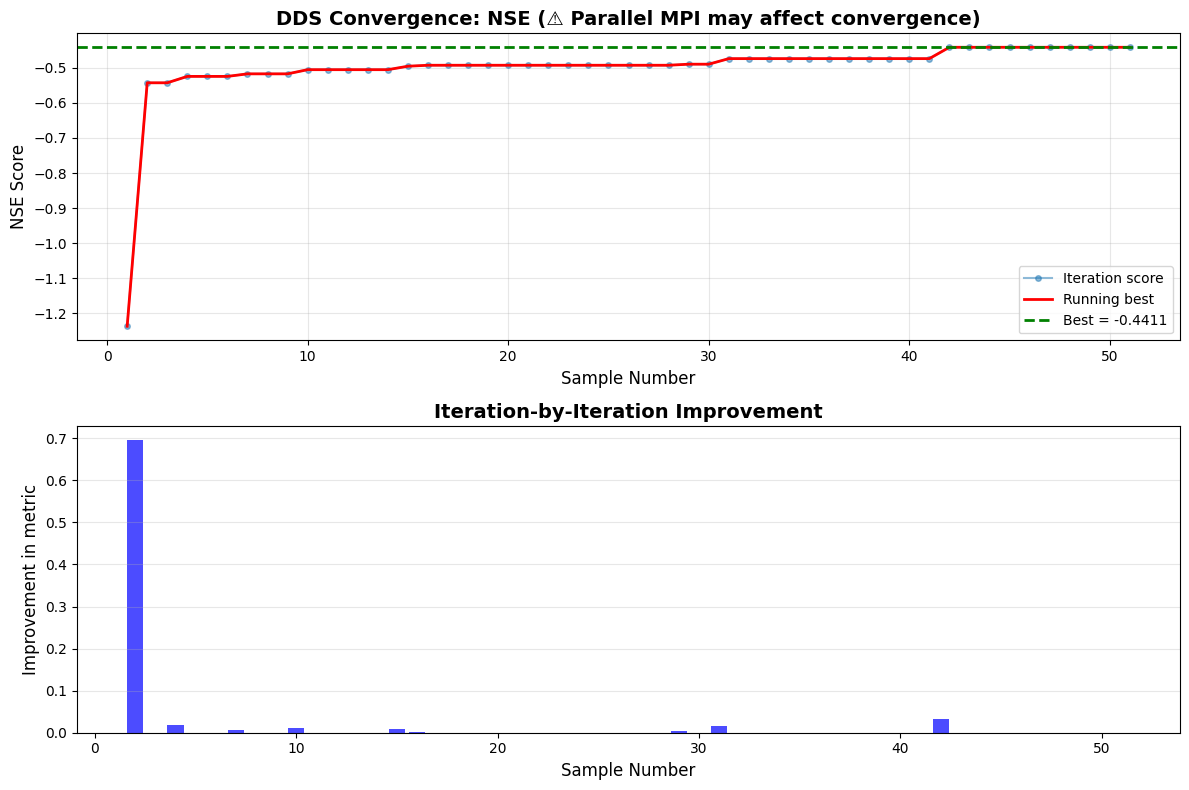


📊 Convergence statistics:
   Mean improvement per iteration: 0.015924
   Median improvement: 0.000000
   Max improvement: 0.694848


In [ ]:
if 'dds_history' in locals():
    # Get metric column and optimization algorithm
    metric_col = config_dict.get('OPTIMIZATION_METRIC', 'NSE')
    opt_algorithm = config_dict.get('ITERATIVE_OPTIMIZATION_ALGORITHM', 'DDS')
    
    # Check if iteration column is valid, otherwise use index
    if 'iteration' in dds_history.columns and dds_history['iteration'].max() > 0:
        iter_vals = dds_history['iteration']
        iter_label = 'Iteration'
    else:
        print("⚠️  Using DataFrame index as iteration numbers (iteration column invalid)")
        iter_vals = dds_history.index + 1  # 1-indexed
        iter_label = 'Sample Number'
    
    # Algorithm-specific warnings
    mpi_procs = config_dict.get('MPI_PROCESSES', 1)
    parallel_algorithms = ['PSO', 'SCE', 'GA', 'DE']
    
    if opt_algorithm == 'DDS' and mpi_procs > 1:
        print(f"\n⚠️⚠️⚠️  CRITICAL WARNING ⚠️⚠️⚠️")
        print(f"   DDS is a SEQUENTIAL algorithm - each iteration needs the previous best!")
        print(f"   Config has MPI_PROCESSES = {mpi_procs}")
        print(f"   Running DDS in parallel defeats convergence and may cause poor results.")
        print(f"   RECOMMENDATION: Set MPI_PROCESSES = 1 for DDS optimization.\n")
    elif opt_algorithm in parallel_algorithms and mpi_procs == 1:
        print(f"\n💡 INFO: {opt_algorithm} can use parallel processing")
        print(f"   Current setting: MPI_PROCESSES = {mpi_procs}")
        print(f"   Consider increasing MPI_PROCESSES for faster execution.\n")
    
    # Find best score and iteration
    best_idx = dds_history[metric_col].idxmax()
    best_score = dds_history[metric_col].max()
    best_iter_num = iter_vals.iloc[best_idx] if hasattr(iter_vals, 'iloc') else iter_vals[best_idx]
    
    print(f"\n📈 Convergence Summary ({opt_algorithm} Algorithm):")
    print(f"   Algorithm: {opt_algorithm}")
    print(f"   Best {metric_col}: {best_score:.6f}")
    print(f"   Best at {iter_label.lower()}: {int(best_iter_num)}")
    print(f"   Total samples: {len(dds_history)}")
    print(f"   Improvement: {dds_history[metric_col].iloc[0]:.6f} → {best_score:.6f}")
    print(f"   MPI Processes: {mpi_procs}")
    
    # Create convergence plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Running best score
    ax1 = axes[0]
    running_best = dds_history[metric_col].expanding().max()
    ax1.plot(iter_vals, dds_history[metric_col], 'o-', 
             alpha=0.5, label='Iteration score', markersize=4)
    ax1.plot(iter_vals, running_best, 'r-', linewidth=2, 
             label='Running best')
    ax1.axhline(best_score, color='g', linestyle='--', linewidth=2, 
                 label=f'Best = {best_score:.4f}')
    ax1.set_xlabel(iter_label, fontsize=12)
    ax1.set_ylabel(f'{metric_col} Score', fontsize=12)
    title_suffix = " (⚠️ Parallel MPI may affect convergence)" if mpi_procs > 1 else ""
    ax1.set_title(f'{opt_algorithm} Convergence: {metric_col}{title_suffix}', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Rate of improvement
    ax2 = axes[1]
    improvement = running_best.diff()
    ax2.bar(iter_vals, improvement, width=0.8, alpha=0.7, color='blue')
    ax2.set_xlabel(iter_label, fontsize=12)
    ax2.set_ylabel('Improvement in metric', fontsize=12)
    ax2.set_title('Iteration-by-Iteration Improvement', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Convergence statistics:")
    print(f"   Mean improvement per iteration: {improvement.mean():.6f}")
    print(f"   Median improvement: {improvement.median():.6f}")
    print(f"   Max improvement: {improvement.max():.6f}")

## Parameter Sensitivity Analysis


📋 Parameters analyzed: 7

🔍 Parameter Sensitivity (correlation with NSE):
   aquiferScaleFactor       : 0.9671
   theta_sat                : 0.7527
   theta_res                : 0.3443
   k_soil                   : 0.2677
   basin__aquiferHydCond    : 0.2486
   rootingDepth             : 0.1986
   basin__aquiferScaleFactor: 0.1654


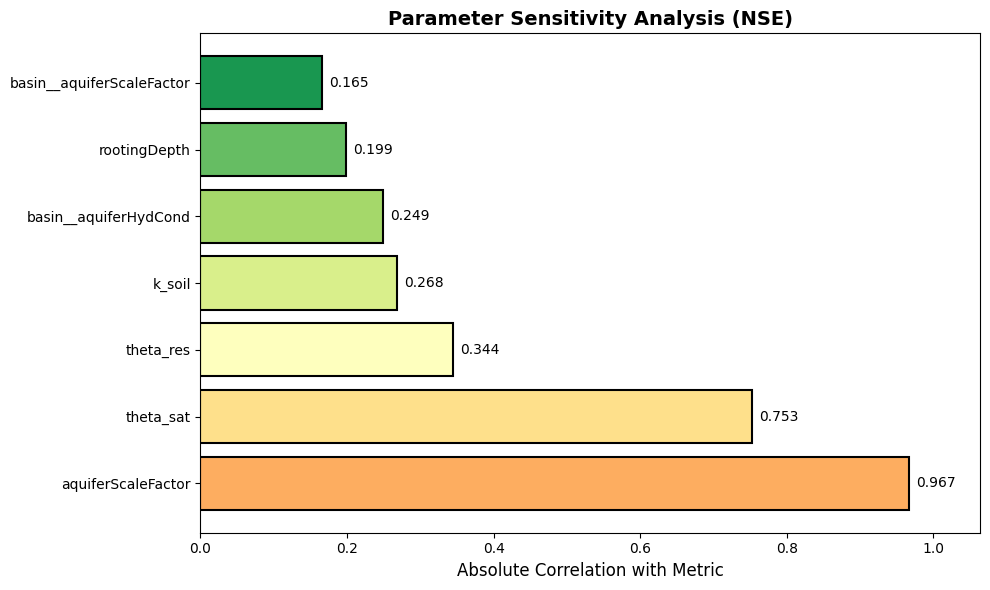

In [39]:
if 'dds_history' in locals():
    metric_col = config_dict.get('OPTIMIZATION_METRIC', 'NSE')
    param_cols = [c for c in dds_history.columns if c not in ['iteration', metric_col]]
    
    print(f"\n📋 Parameters analyzed: {len(param_cols)}")
    
    # Calculate parameter sensitivity (correlation with metric)
    sensitivity = {}
    for param in param_cols:
        # Correlation between parameter value and metric
        corr = dds_history[[param, metric_col]].corr().iloc[0, 1]
        sensitivity[param] = abs(corr)  # Use absolute correlation for sensitivity
    
    # Sort by sensitivity
    sensitivity_sorted = sorted(sensitivity.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n🔍 Parameter Sensitivity (correlation with {metric_col}):")
    for param, sens in sensitivity_sorted:
        print(f"   {param:25s}: {sens:.4f}")
    
    # Create sensitivity plot
    params = [p[0] for p in sensitivity_sorted]
    sensitivities = [p[1] for p in sensitivity_sorted]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(params)))
    bars = ax.barh(params, sensitivities, color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Absolute Correlation with Metric', fontsize=12)
    ax.set_title(f'Parameter Sensitivity Analysis ({metric_col})', fontsize=14, fontweight='bold')
    ax.set_xlim(0, max(sensitivities) * 1.1)
    
    # Add value labels
    for i, (param, sens) in enumerate(sensitivity_sorted):
        ax.text(sens + 0.01, i, f'{sens:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## Parameter Ranges During Optimization

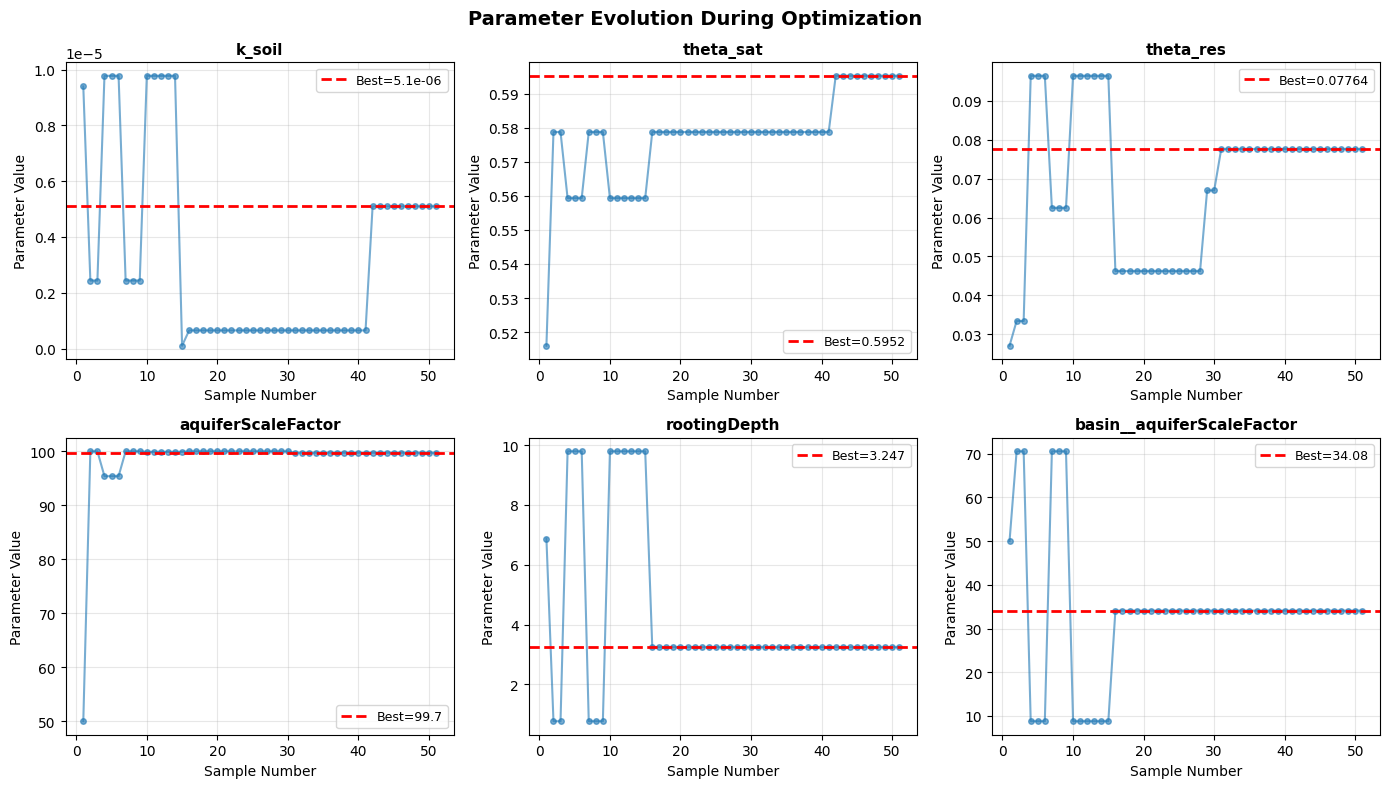

In [40]:
if 'dds_history' in locals() and 'best_params_df' in locals():
    # Use same iteration values as convergence plot
    if 'iteration' in dds_history.columns and dds_history['iteration'].max() > 0:
        iter_vals = dds_history['iteration']
        iter_label = 'Iteration'
    else:
        iter_vals = dds_history.index + 1
        iter_label = 'Sample Number'
    
    # Create parameter variation plot
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(best_params_df.iterrows()):
        if idx >= len(axes):
            break
        
        param = row['parameter']
        best_value = row['value']
        
        if param in dds_history.columns:
            ax = axes[idx]
            
            # Plot parameter evolution
            ax.plot(iter_vals, dds_history[param], 'o-', 
                   alpha=0.6, markersize=4)
            ax.axhline(best_value, color='r', linestyle='--', linewidth=2, 
                       label=f'Best={best_value:.4g}')
            
            ax.set_xlabel(iter_label, fontsize=10)
            ax.set_ylabel('Parameter Value', fontsize=10)
            ax.set_title(param, fontsize=11, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(best_params_df), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Parameter Evolution During Optimization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Load and Validate Best Model

Compare simulated streamflow from best optimization parameters against observations.

In [41]:
import geopandas as gpd

# Load observations
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{DOMAIN_NAME}_streamflow_processed.csv"

if obs_path.exists():
    obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
    obs_df.set_index('datetime', inplace=True)
    
    print(f"✓ Loaded observations from: {obs_path.name}")
    print(f"  Date range: {obs_df.index.min()} to {obs_df.index.max()}")
    print(f"  Columns: {list(obs_df.columns)}")
    print(f"\n  Statistics:")
    print(obs_df.describe())
else:
    print(f"⚠️  Observations file not found: {obs_path}")
    obs_df = None

✓ Loaded observations from: Tuolumne_River_lumped_streamflow_processed.csv
  Date range: 2013-10-01 00:00:00 to 2026-02-23 00:00:00
  Columns: ['discharge_cms']

  Statistics:
       discharge_cms
count  105411.000000
mean       14.230300
std        24.479694
min         0.109869
25%         1.146830
50%         4.813856
75%        14.903486
max       193.403744


In [42]:
if obs_df is not None and 'latest_dds_folder' in locals():
    # Find best simulation output
    summa_dir = project_dir / "simulations" / "run_dds" / "SUMMA" 
    
    if summa_dir.exists():
        # Find the output file with highest iteration number
        output_files = list(summa_dir.glob(f"*{config_dict['EXPERIMENT_ID']}_timestep.nc"))
        
        if output_files:
            best_sim_file = output_files[-1]  # Assuming last is best
            print(f"✓ Loading best simulation: {best_sim_file.name}")
            
            # Load simulated streamflow
            best_sim_ds = xr.open_dataset(best_sim_file)
            
            # Extract streamflow variable
            if 'scalarTotalRunoff' in best_sim_ds.data_vars:
                # Convert m/s to m³/s using basin area
                shp_file = gpd.read_file(str(project_dir / "shapefiles" / "catchment" / 
                                             f"{DOMAIN_NAME}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
                shp_area = shp_file['GRU_area'].max() if 'GRU_area' in shp_file.columns else 1.0
                sim_q = best_sim_ds['scalarTotalRunoff'] * shp_area
            else:
                print(f"⚠️  No streamflow variable found in: {list(best_sim_ds.data_vars)}")
                sim_q = None
            
            if sim_q is not None:
                sim_df = sim_q.to_pandas()
                if isinstance(sim_df, pd.DataFrame):
                    sim_df = sim_df.iloc[:, 0]
                
                print(f"\n✓ Simulation loaded")
                print(f"  Date range: {sim_df.index.min()} to {sim_df.index.max()}")
                print(f"\n  Statistics:")
                print(sim_df.describe())
        else:
            print(f"⚠️  No output files found in {summa_dir}")
    else:
        print(f"⚠️  SUMMA output directory not found: {summa_dir}")

✓ Loading best simulation: run_dds_final_20260225_spongy_parkingLot_timestep.nc

✓ Simulation loaded
  Date range: 2011-10-01 00:00:00 to 2022-09-30 23:00:00.000013312

  Statistics:
count    96432.000000
mean        19.996806
std        189.596485
min          1.133531
25%          3.075755
50%          6.991125
75%         18.090890
max      22340.355964
Name: 1, dtype: float64


## Model Performance Metrics

In [43]:
if obs_df is not None and 'sim_df' in locals():
    # Get calibration period from config
    cal_period = config_dict.get('CALIBRATION_PERIOD', '2013-10-01, 2015-09-30')
    cal_start, cal_end = [s.strip() for s in cal_period.split(',')]
    
    # Align time series
    common_start = max(obs_df.index.min(), sim_df.index.min())
    common_end = min(obs_df.index.max(), sim_df.index.max())
    
    # Extract calibration period
    obs_cal = obs_df['discharge_cms'].loc[cal_start:cal_end]
    sim_cal = sim_df.loc[cal_start:cal_end]
    
    def calculate_metrics(obs, sim):
        """Calculate NSE, KGE, and correlation"""
        valid = ~(obs.isna() | sim.isna())
        o, s = obs[valid], sim[valid]
        
        # NSE
        nse = 1 - ((o - s) ** 2).sum() / ((o - o.mean()) ** 2).sum()
        
        # KGE
        r = o.corr(s)
        alpha = s.std() / o.std()
        beta = s.mean() / o.mean()
        kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
        
        return {'NSE': nse, 'KGE': kge, 'r': r, 'alpha': alpha, 'beta': beta}
    
    metrics_cal = calculate_metrics(obs_cal, sim_cal)
    metrics_full = calculate_metrics(obs_df['discharge_cms'].loc[common_start:common_end], 
                                     sim_df.loc[common_start:common_end])
    
    print("=" * 60)
    print("BEST MODEL PERFORMANCE")
    print("=" * 60)
    print(f"\n📊 Calibration Period ({cal_start} to {cal_end}):")
    print(f"   NSE:   {metrics_cal['NSE']:.4f}")
    print(f"   KGE:   {metrics_cal['KGE']:.4f}")
    print(f"   r:     {metrics_cal['r']:.4f}")
    print(f"   α:     {metrics_cal['alpha']:.4f} (bias in variability)")
    print(f"   β:     {metrics_cal['beta']:.4f} (bias in mean)")
    
    print(f"\n📊 Full Period ({common_start.date()} to {common_end.date()}):")
    print(f"   NSE:   {metrics_full['NSE']:.4f}")
    print(f"   KGE:   {metrics_full['KGE']:.4f}")
    print(f"   r:     {metrics_full['r']:.4f}")

BEST MODEL PERFORMANCE

📊 Calibration Period (2013-10-01 to 2015-09-30):
   NSE:   0.5198
   KGE:   -0.0048
   r:     0.0530
   α:     0.7077 (bias in variability)
   β:     1.1659 (bias in mean)

📊 Full Period (2013-10-01 to 2022-09-30):
   NSE:   0.3543
   KGE:   -0.0945
   r:     -0.0745


## Streamflow Comparison Plots

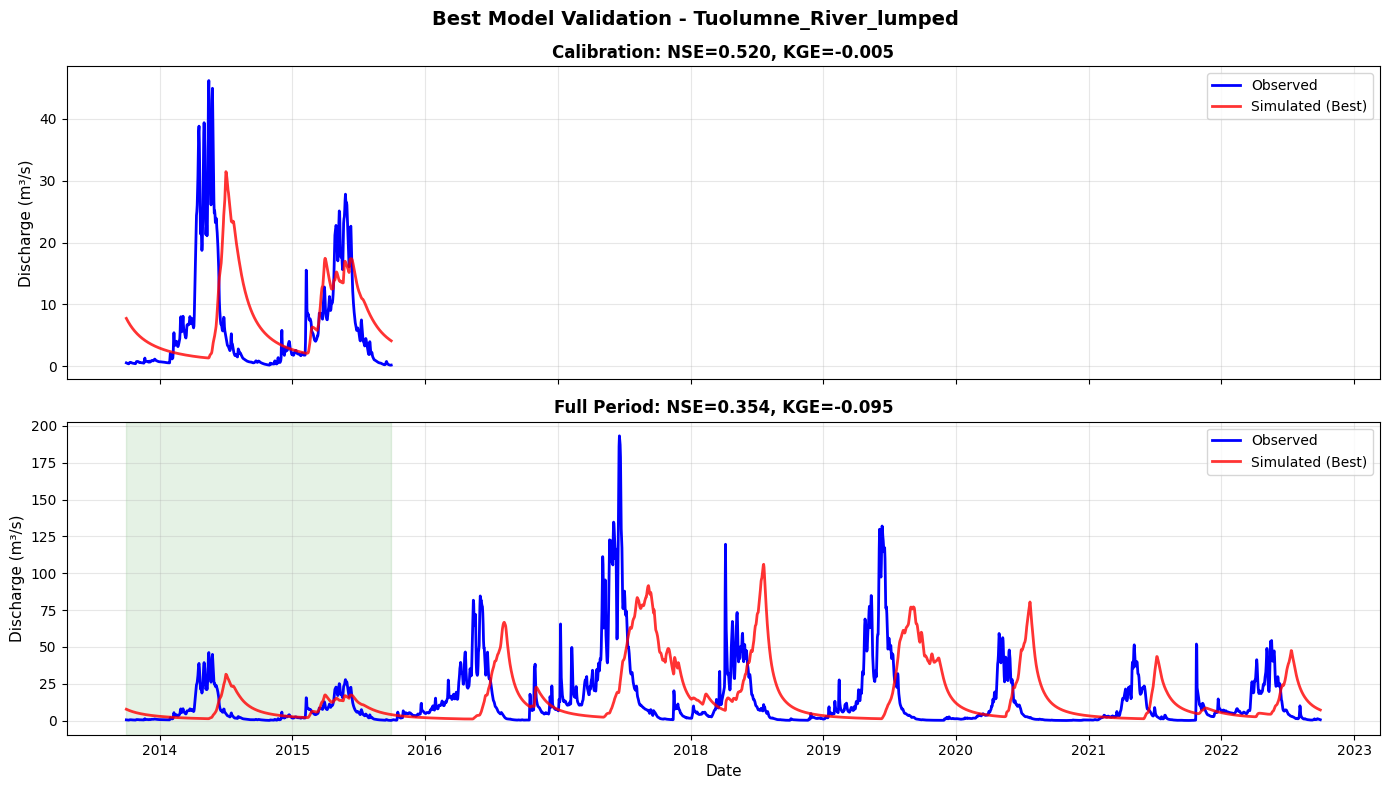

In [30]:
if obs_df is not None and 'sim_df' in locals() and 'metrics_cal' in locals():
    # Create comparison plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Calibration period
    ax1 = axes[0]
    obs_cal_daily = obs_cal.resample('D').mean()
    sim_cal_daily = sim_cal.resample('D').mean()
    ax1.plot(obs_cal_daily.index, obs_cal_daily.values, 'b-', label='Observed', linewidth=2)
    ax1.plot(sim_cal_daily.index, sim_cal_daily.values, 'r-', label='Simulated (Best)', 
            linewidth=2, alpha=0.8)
    ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
    ax1.set_title(f'Calibration: NSE={metrics_cal["NSE"]:.3f}, KGE={metrics_cal["KGE"]:.3f}', 
                 fontweight='bold', fontsize=12)
    ax1.legend(fontsize=10, loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Full simulation
    ax2 = axes[1]
    obs_full_daily = obs_df['discharge_cms'].loc[common_start:common_end].resample('D').mean()
    sim_full_daily = sim_df.loc[common_start:common_end].resample('D').mean()
    ax2.plot(obs_full_daily.index, obs_full_daily.values, 'b-', label='Observed', linewidth=2)
    ax2.plot(sim_full_daily.index, sim_full_daily.values, 'r-', label='Simulated (Best)', 
            linewidth=2, alpha=0.8)
    ax2.set_ylabel('Discharge (m³/s)', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_title(f'Full Period: NSE={metrics_full["NSE"]:.3f}, KGE={metrics_full["KGE"]:.3f}', 
                 fontweight='bold', fontsize=12)
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # Shade calibration period in full plot
    ax2.axvspan(pd.Timestamp(cal_start), pd.Timestamp(cal_end), alpha=0.1, color='green')
    
    plt.suptitle(f'Best Model Validation - {DOMAIN_NAME}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Scatter Plot: Observed vs Simulated

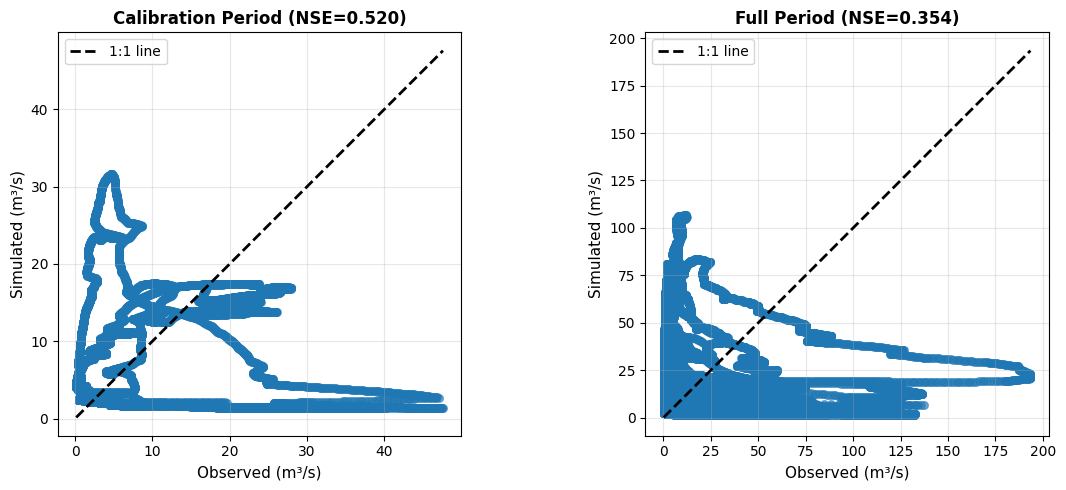

In [31]:
if obs_df is not None and 'sim_df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Calibration period
    ax1 = axes[0]
    ax1.scatter(obs_cal, sim_cal, alpha=0.6, s=30)
    
    # Add 1:1 line
    lim = [min(obs_cal.min(), sim_cal.min()), max(obs_cal.max(), sim_cal.max())]
    ax1.plot(lim, lim, 'k--', linewidth=2, label='1:1 line')
    
    ax1.set_xlabel('Observed (m³/s)', fontsize=11)
    ax1.set_ylabel('Simulated (m³/s)', fontsize=11)
    ax1.set_title(f'Calibration Period (NSE={metrics_cal["NSE"]:.3f})', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_aspect('equal')
    
    # Full period
    ax2 = axes[1]
    obs_full_aligned = obs_df['discharge_cms'].loc[common_start:common_end]
    sim_full_aligned = sim_df.loc[common_start:common_end]
    ax2.scatter(obs_full_aligned, sim_full_aligned, alpha=0.6, s=30)
    
    lim = [min(obs_full_aligned.min(), sim_full_aligned.min()), 
           max(obs_full_aligned.max(), sim_full_aligned.max())]
    ax2.plot(lim, lim, 'k--', linewidth=2, label='1:1 line')
    
    ax2.set_xlabel('Observed (m³/s)', fontsize=11)
    ax2.set_ylabel('Simulated (m³/s)', fontsize=11)
    ax2.set_title(f'Full Period (NSE={metrics_full["NSE"]:.3f})', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

## Export Results Summary

In [ ]:
if 'best_params_df' in locals():
    # Create summary report
    summary = f"""
CONFLUENCE DDS Optimization Summary
====================================

Optimization Run: {config_dict['EXPERIMENT_ID']}
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

Configuration:
  Domain: {DOMAIN_NAME}
  Iterations: {len(dds_history) if 'dds_history' in locals() else 'N/A'}
  Metric: {config_dict.get('OPTIMIZATION_METRIC', 'NSE')}
  Basin Area: {config_dict.get('BASIN_AREA_M2', 'N/A')} m²

Best Parameters Found:
  {chr(10).join([f'  {p}: {v}' for p, v in best_params_df.set_index('parameter')['value'].items()])}

Performance Metrics:
  Calibration NSE:   {metrics_cal['NSE']:.6f if 'metrics_cal' in locals() else 'N/A'}
  Calibration KGE:   {metrics_cal['KGE']:.6f if 'metrics_cal' in locals() else 'N/A'}
  Full Period NSE:   {metrics_full['NSE']:.6f if 'metrics_full' in locals() else 'N/A'}
  Full Period KGE:   {metrics_full['KGE']:.6f if 'metrics_full' in locals() else 'N/A'}

Results Location: {latest_dds_folder if 'latest_dds_folder' in locals() else 'N/A'}
"""
    
    print(summary)
    
    # Save to file
    summary_file = latest_dds_folder / "optimization_summary.txt"
    with open(summary_file, 'w') as f:
        f.write(summary)
    
    print(f"✓ Summary saved to: {summary_file}")